In [ ]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

In [1]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_LOSS,FOLD_VL_LOSS,FOLD_TR_LOSS
from cross_common import MEE,MSE,RMSE,MAE,LOSS


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [2]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

default_batch_size = [64]
default_epochs = 0

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3)


# ---- The metrics to calculate in train ---
epochs_metrics_dict = {
    LOSS: (nnc.MEELoss, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min)
}
the_metrics = epochs_metrics_dict.keys()
# ------------------------------------------


# ----- Defining model basic architecture --------
base_hidden_layers = ["32"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ----- Learning rate and weight decay -----
base_weight_decay = [0]
base_learning_rates = [1e-4]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------

# Base trial dictionary to progressively update
base_trial_dict={
    "epochs": default_epochs,
    "batch_size": default_batch_size,
    "fold_strategy": base_fold_strategy,
    "input_dimension":input_dimension,
    "output_dimension":output_dimension,
    "hidden_layers": base_hidden_layers,
    "learning_rate": base_learning_rates,
    "weight_decay": base_weight_decay,
    "activation": base_activation_function,
    "output_adapter": output_adapter,
    "metrics": epochs_metrics_dict,
    "scheduler_template": scheduler_template
}

In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = nnc.suggest_trial_param(trial, "batch_size", trial_dict["batch_size"])
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict["metrics"]
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.build_nn_model(net_trial, output_adapter_trial)

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "additional_metrics": metrics_trial
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_LOSS,
    fold_metric=FOLD_VL_LOSS,
    early_epoch=30
)

coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]

<h5>Coarse Grained</h5>

In [7]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

base_trial_dict["learning_rate"] = coarse_learning_rates
base_trial_dict["epochs"] = 100

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-08-11 12:05:18,723] A new study created in memory with name: no-name-69e83e87-63b2-410c-b06b-4d447e575970
  5%|▌         | 1/20 [00:02<00:54,  2.89s/it]

[I 2026-08-11 12:05:21,623] Trial 0 finished with values: [25.189676658434607, 0.23209653053575088, 0.27988717556525183] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


 10%|█         | 2/20 [00:05<00:47,  2.63s/it]

[I 2026-08-11 12:05:24,076] Trial 1 finished with values: [25.357053156800134, 0.1753314189530629, 0.26847525089378355] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:07<00:43,  2.54s/it]

...

[I 2026-08-11 12:06:03,122] Trial 17 finished with values: [25.32810021478818, 0.1663496496999454, 0.26531391841879826] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:46<00:02,  2.43s/it]

[I 2026-08-11 12:06:05,540] Trial 18 finished with values: [25.303196516955044, 0.22362680302287882, 0.2553801768288407] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


100%|██████████| 20/20 [00:49<00:00,  2.46s/it]

[I 2026-08-11 12:06:07,959] Trial 19 finished with values: [25.42872010032339, 0.18032037521805885, 0.2689608035539122] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


In [8]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.003


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor

base_trial_dict["learning_rate"] = (low_lr, high_lr)
base_trial_dict["epochs"] = 100

objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-08-11 12:06:39,901] A new study created in memory with name: no-name-7c65aa11-3f71-4023-9b51-af3fe6e651ba
  3%|▎         | 1/30 [00:02<01:10,  2.42s/it]

[I 2026-08-11 12:06:42,321] Trial 0 finished with values: [25.357439822323627, 0.20028474536724472, 0.28916556616383926] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0020234420773433356, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:04<01:08,  2.43s/it]

[I 2026-08-11 12:06:44,764] Trial 1 finished with values: [24.38175834767864, 0.2759630958930095, 0.24979213516247548] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.005087581833705051, 'weight_decay': 0}.


 10%|█         | 3/30 [00:07<01:05,  2.43s/it]

...

[I 2026-08-11 12:07:50,071] Trial 27 finished with values: [25.454031539049893, 0.12101612113155187, 0.21943901863309037] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0015018104615525485, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [01:12<00:02,  2.47s/it]

[I 2026-08-11 12:07:52,479] Trial 28 finished with values: [25.50762172968039, 0.18952127445178124, 0.2477784729049636] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0022429358311928894, 'weight_decay': 0}.


100%|██████████| 30/30 [01:14<00:00,  2.50s/it]

[I 2026-08-11 12:07:54,898] Trial 29 finished with values: [25.317871979194965, 0.10631797483510101, 0.2008152389695822] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0}.


In [10]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
base_trial_dict["learning_rate"] = [final_lr]
print(coarse_grained_lr, final_lr)

0.003 0.0010152816346943616


<h4>Batch Size</h4>
<hr>

In [11]:
evaluate_batch_size_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

# online and batch are excluded as they respectively noisy and inefficient
batch_sizes = [16, 32, 64, 128]

In [12]:
# as we are testing few lr a small
# nr of trials is enough
batch_sizes_trials_nr = 20

base_trial_dict["batch_size"] = batch_sizes

objective_batch_size_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_batch_size_partial,
    trial_dict=base_trial_dict
)

batch_size_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)

batch_size_study.optimize(objective_batch_size_partial, show_progress_bar=True, n_trials=batch_sizes_trials_nr)

[I 2026-08-11 12:11:03,182] A new study created in memory with name: no-name-d0713b64-57c9-4b37-8bdc-a359c147ab0b
  5%|▌         | 1/20 [00:06<02:09,  6.83s/it]

[I 2026-08-11 12:11:10,013] Trial 0 finished with values: [25.10904302744513, 0.19833890819919375] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0}.


 10%|█         | 2/20 [00:10<01:34,  5.24s/it]

[I 2026-08-11 12:11:14,132] Trial 1 finished with values: [25.436084234688423, 0.21182767646156364] and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:14<01:19,  4.68s/it]

...

[I 2026-08-11 12:12:17,592] Trial 17 finished with values: [25.23278354872008, 0.27247698431201073] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [01:18<00:03,  3.96s/it]

[I 2026-08-11 12:12:21,464] Trial 18 finished with values: [25.50665983380749, 0.2161066943027805] and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0}.


100%|██████████| 20/20 [01:19<00:00,  4.00s/it]

[I 2026-08-11 12:12:23,107] Trial 19 finished with values: [25.584040079643618, 0.16530800609810825] and parameters: {'batch_size': 128, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0}.


In [15]:
importlib.reload(nnc)
final_batch_size = nnc.find_best_batch_size_from_trials(batch_size_study)
base_trial_dict["batch_size"] = [final_batch_size]
print(final_batch_size)

16


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [14]:

evaluate_wd_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS
)

coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [16]:
coarse_grained_wd_trials_nr = 20

base_trial_dict["weight_decay"] = coarse_weight_decays

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict=base_trial_dict
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-08-11 12:14:26,034] A new study created in memory with name: no-name-b57406f0-e431-4b50-9d67-faf614a4d403
  5%|▌         | 1/20 [00:06<02:09,  6.81s/it]

[I 2026-08-11 12:14:32,845] Trial 0 finished with values: [25.213940189602752, 0.2286521057203892] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0.0001}.


 10%|█         | 2/20 [00:13<02:02,  6.83s/it]

[I 2026-08-11 12:14:39,684] Trial 1 finished with values: [25.130156379492195, 0.24551624237631842] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 1e-05}.


 15%|█▌        | 3/20 [00:20<01:55,  6.81s/it]

...

[I 2026-08-11 12:16:31,116] Trial 17 finished with values: [25.217620023793426, 0.23938598019432078] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0.0005}.


 95%|█████████▌| 19/20 [02:11<00:06,  6.81s/it]

[I 2026-08-11 12:16:37,853] Trial 18 finished with values: [25.400282727953325, 0.24130355699355377] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 1e-05}.


100%|██████████| 20/20 [02:18<00:00,  6.93s/it]

[I 2026-08-11 12:16:44,608] Trial 19 finished with values: [25.264760336662516, 0.21688090818918937] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0.0005}.


In [17]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

0.0


<h5>Fine Grained</h5>

In [18]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))

base_trial_dict["weight_decay"] = (low_wd, high_wd)

objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict=base_trial_dict
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-08-11 12:19:27,068] A new study created in memory with name: no-name-c5ee78ed-9b94-43b4-8e40-c85a0126f7ad
  3%|▎         | 1/30 [00:06<03:20,  6.91s/it]

[I 2026-08-11 12:19:33,974] Trial 0 finished with values: [25.21906554540411, 0.2546419377208835] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0.0004174981850554847}.


  7%|▋         | 2/30 [00:13<03:14,  6.95s/it]

[I 2026-08-11 12:19:40,953] Trial 1 finished with values: [25.252967060625682, 0.22738501930595945] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 1.0014732218143888e-05}.


 10%|█         | 3/30 [00:20<03:07,  6.94s/it]

...

[I 2026-08-11 12:22:46,265] Trial 27 finished with values: [25.268486037443655, 0.23913148147623886] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 0.00019625828353497888}.


 97%|█████████▋| 29/30 [03:26<00:06,  6.96s/it]

[I 2026-08-11 12:22:53,201] Trial 28 finished with values: [25.31957101433164, 0.22991685788171168] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 4.95994512924269e-05}.


100%|██████████| 30/30 [03:33<00:00,  7.10s/it]

[I 2026-08-11 12:23:00,095] Trial 29 finished with values: [25.274953474573156, 0.2395115013059339] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 4.609113091334933e-05}.


In [19]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
base_trial_dict["weight_decay"] = [final_weight_decay]
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 0.0 Fine grained WD: 2.5992083357980537e-05


<h4>Model Capacity</h4>
<hr/>

In [30]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_LOSS,
    vl_key=FOLD_VL_LOSS
)

base_trial_dict["hidden_layers"] = base_hidden_layers + ["64","128","256","128,64","256,128","32,16,8","64,32,16","128,64,32"]
base_trial_dict["fold_strategy"] = cr.common_fold_strategy(n_split=5)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict=base_trial_dict
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)



[I 2026-08-11 13:56:07,509] A new study created in memory with name: no-name-0b29d0a7-bd32-4965-9e1b-ced4ba47f736
  3%|▎         | 1/30 [00:21<10:12, 21.14s/it]

[I 2026-08-11 13:56:28,645] Trial 0 finished with values: [23.848137115478515, 0.5677522354125983] and parameters: {'batch_size': 16, 'hidden_layers': '256', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


  7%|▋         | 2/30 [00:44<10:30, 22.51s/it]

[I 2026-08-11 13:56:52,111] Trial 1 finished with values: [22.61636929321289, 2.197457595825199] and parameters: {'batch_size': 16, 'hidden_layers': '256,128', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


 10%|█         | 3/30 [01:05<09:45, 21.69s/it]

...

[I 2026-08-11 14:06:25,613] Trial 27 finished with values: [25.50318473815918, 0.20807205200195256] and parameters: {'batch_size': 16, 'hidden_layers': '64', 'activation': 'tanh', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


 97%|█████████▋| 29/30 [10:38<00:21, 21.64s/it]

[I 2026-08-11 14:06:46,483] Trial 28 finished with values: [25.292108963012694, 0.2645788269042981] and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


100%|██████████| 30/30 [11:01<00:00, 22.06s/it]

[I 2026-08-11 14:07:09,369] Trial 29 finished with values: [24.21115490722656, 0.4972137145996065] and parameters: {'batch_size': 16, 'hidden_layers': '32,16,8', 'activation': 'gelu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


In [34]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
base_trial_dict["hidden_layers"] = [", ".join(map(str, final_hidden_layers))]
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [128, 64, 32] - best metrics: 21.647633613586425 - best VL/TR gap: 2.8474191665649435


<h4>Activation Function</h4>
<hr/>

In [35]:
base_trial_dict["hidden_layers"]

['128, 64, 32']

In [36]:
activation_trials_nr=10

evaluate_activation_partial = partial(
    nnc.evaluate_architecture, # we re use architecture function as we are evaluating an architecture
    tr_key=FOLD_TR_LOSS,
    vl_key=FOLD_VL_LOSS
)

base_trial_dict["activation"] = ["relu", "tanh", "gelu"]

objective_activation_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_activation_partial,
    trial_dict=base_trial_dict
)

activation_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
activation_study.optimize(objective_activation_model, show_progress_bar=True, n_trials=activation_trials_nr)


[I 2026-08-11 14:10:40,783] A new study created in memory with name: no-name-42e1fb1c-8cf9-48e1-9c1b-f6fe276b3a54
 10%|█         | 1/10 [00:24<03:41, 24.58s/it]

[I 2026-08-11 14:11:05,363] Trial 0 finished with values: [21.637428535461428, 2.504172401428228] and parameters: {'batch_size': 16, 'hidden_layers': '128, 64, 32', 'activation': 'gelu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


 20%|██        | 2/10 [00:49<03:16, 24.53s/it]

[I 2026-08-11 14:11:29,859] Trial 1 finished with values: [22.565624084472656, 2.137656677246092] and parameters: {'batch_size': 16, 'hidden_layers': '128, 64, 32', 'activation': 'tanh', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


 30%|███       | 3/10 [01:14<02:53, 24.84s/it]

...

[I 2026-08-11 14:13:53,069] Trial 7 finished with values: [22.119218811035154, 2.314623855590817] and parameters: {'batch_size': 16, 'hidden_layers': '128, 64, 32', 'activation': 'tanh', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


 90%|█████████ | 9/10 [03:36<00:23, 23.78s/it]

[I 2026-08-11 14:14:16,992] Trial 8 finished with values: [21.375877113342284, 2.6626523742675765] and parameters: {'batch_size': 16, 'hidden_layers': '128, 64, 32', 'activation': 'gelu', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


100%|██████████| 10/10 [04:00<00:00, 24.01s/it]

[I 2026-08-11 14:14:40,888] Trial 9 finished with values: [22.157075340271, 1.824243408203131] and parameters: {'batch_size': 16, 'hidden_layers': '128, 64, 32', 'activation': 'tanh', 'learning_rate': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05}.


In [37]:
importlib.reload(nnc)
final_activation = nnc.find_best_activation_from_trials(activation_study)
print(f"Base activation function: {base_activation_function} Final activation function: {final_activation}")

Base activation function: ['relu'] Final activation function: gelu


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [45]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, final_activation)
model_template = nnc.build_nn_model(net, output_adapter)

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=1000
kv_batch_size=final_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": epochs_metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 149 (best VL loss: 21.0714)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 100 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 164 (best VL loss: 20.3458)
Train summary
--------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

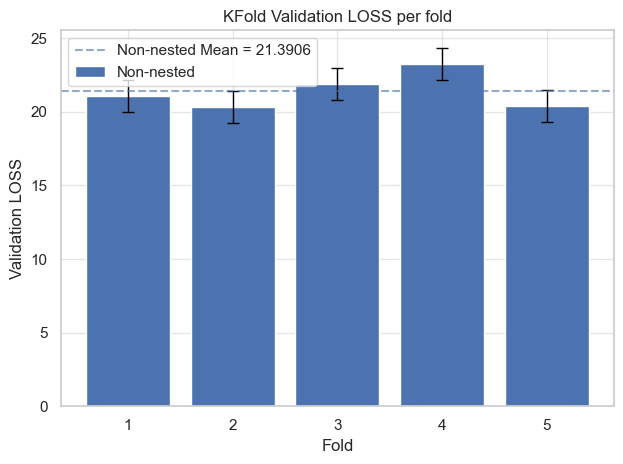

,TR,VL,|TR-VL|
Fold,,,
1,17.772268,21.071423,3.299155
2,17.841652,20.345827,2.504175
3,19.596478,21.884276,2.287798
4,19.709832,23.241885,3.532052
5,18.810820,20.409553,1.598733
MEAN,18.746210,21.390593,2.644383
STD,0.827343,1.079523,0.700982


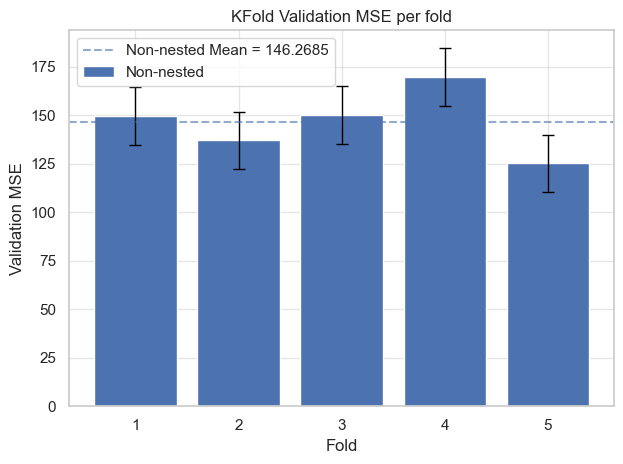

,TR,VL,|TR-VL|
Fold,,,
1,112.189599,149.489071,37.299472
2,110.719048,137.026212,26.307163
3,130.481818,150.034333,19.552516
4,141.224124,169.620117,28.395993
5,122.410835,125.172999,2.762164
MEAN,123.405085,146.268546,22.863462
STD,11.448227,14.834363,11.540285


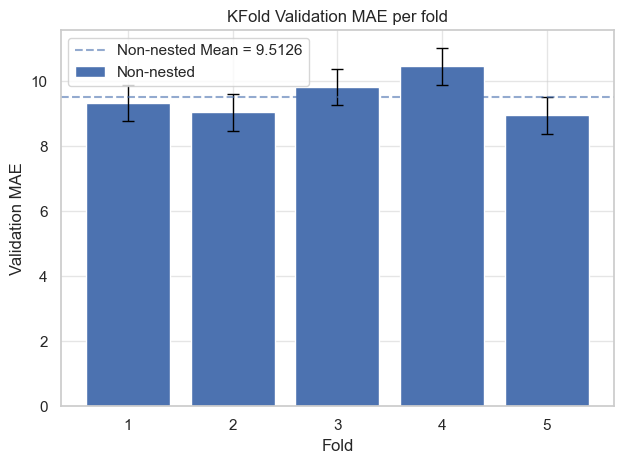

,TR,VL,|TR-VL|
Fold,,,
1,7.881334,9.331070,1.449736
2,7.910294,9.032900,1.122606
3,8.699736,9.810918,1.111182
4,8.567082,10.447841,1.880759
5,8.088067,8.940380,0.852313
MEAN,8.229303,9.512622,1.283319
STD,0.340058,0.557525,0.353795


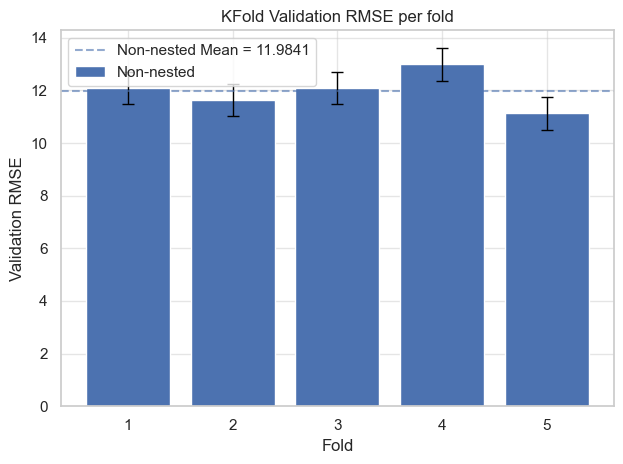

,TR,VL,|TR-VL|
Fold,,,
1,10.306387,12.096241,1.789854
2,10.449537,11.628373,1.178835
3,11.302583,12.085943,0.783359
4,11.758181,12.985322,1.227141
5,10.955523,11.124835,0.169313
MEAN,10.954442,11.984143,1.029700
STD,0.537048,0.614861,0.536658


In [46]:
importlib.reload(cr)
for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))


<h4>Bootstrap Variance</h4>

In [47]:

epochs_metrics_bootstrap_dict = {
    MEE: (cr.mee, min)
}

importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, epochs_metrics_bootstrap_dict, bootstrap_params)

In [48]:
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MEE,24.69,0.78,3.16


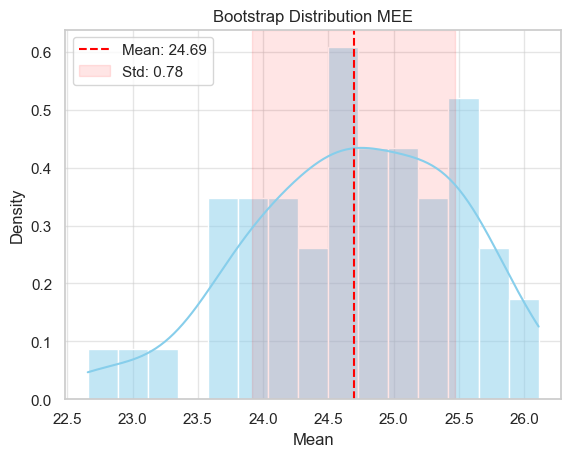

In [49]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title=f"Bootstrap Distribution {MEE.upper()}")

<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [50]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=scaler), # 0.1 = 10%
    **inner_train_params
)

Early stopping at epoch 109 (best VL loss: 19.4073)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 450
Validation      | samples: 50
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0010152816346943616, 'weight_decay': 2.5992083357980537e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 60 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------


In [51]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_loss
epochs_kf_tr_mee = train_kf_result.epochs_tr_loss
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_grad = train_kf_result.epochs_grad_norm

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

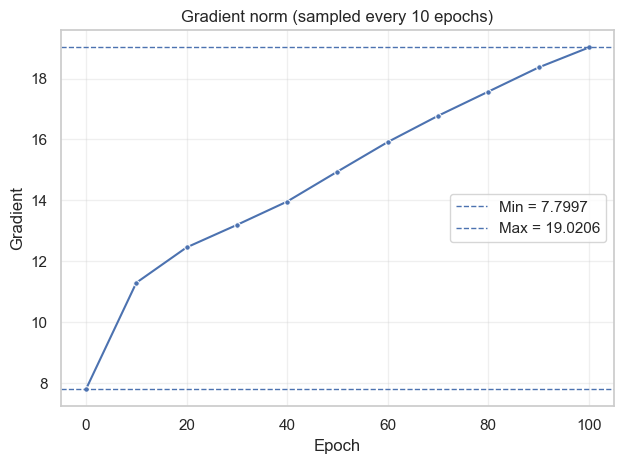

In [52]:
importlib.reload(nnc)
importlib.reload(cr)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

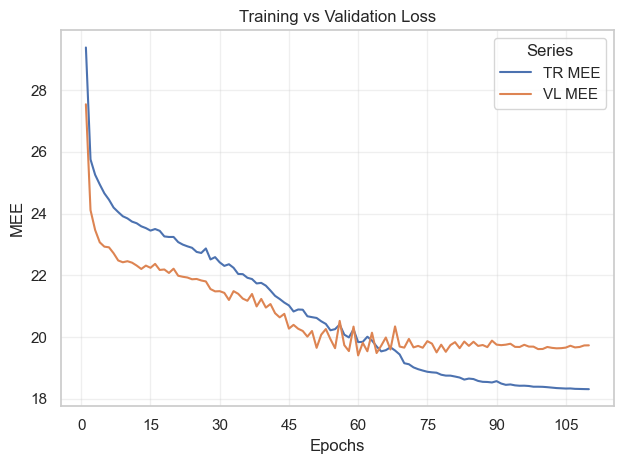

In [53]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

<Figure size 640x480 with 0 Axes>

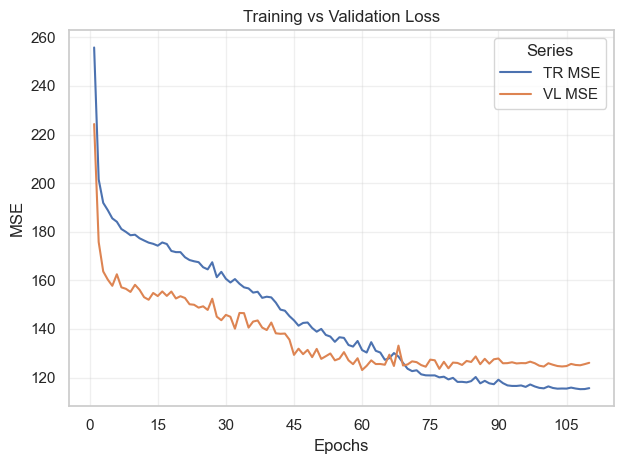

In [54]:
importlib.reload(nnc)
nnc.plot_epoch_mse(epochs_kf_tr_mse, epochs_kf_vl_mse)

In [55]:
importlib.reload(cc)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_mee)
print(f"{mean:.4f} ± {std:.4f}")

20.7037 ± 1.3196


<h3>Best Hyperparameters</h3>
<hr/>

In [56]:
print(f"hidden layers: {final_hidden_layers}")
print(f"activation function: {final_activation}")
for key, value in inner_train_params.items():
    print(f"{key}: {value}")



hidden layers: [128, 64, 32]
activation function: gelu
epochs: 1000
batch_size: 16
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.0010152816346943616, weight_decay=2.5992083357980537e-05, betas=(0.95, 0.999))
loss_function: MEELoss(reduction='mean') - custom function
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.01
additional_metrics: {'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>), 'mse': (<function mse at 0x11dc57530>, <built-in function min>), 'mae': (<function mae at 0x11dc577f0>, <built-in function min>), 'rmse': (<function rmse at 0x11dc575e0>, <built-in function min>)}
